# 3.6e — Génération conditionnelle et *classifier-free guidance*, from scratch

## Pourquoi ce notebook

Le `3.6c` écrit le DDPM **inconditionnel** à la main : forward en forme fermée, réseau $\varepsilon_\theta$, sampler ancestral, comparaison de schedules. Le `3.6d` passe la même mécanique en temps continu.

Il manque la pièce qui fait tourner les générateurs d'images du quotidien : **conditionner**. Un modèle inconditionnel sait produire *un* chiffre ; il ne sait pas produire *le* chiffre qu'on lui demande, ni arbitrer entre fidélité et diversité.

Ce notebook ajoute deux mécanismes, et deux seulement :

1. **Le conditionnement par étiquette** — le réseau ne prédit plus le bruit « en général », mais le bruit d'une image **de la classe demandée**.
2. **Le *classifier-free guidance*** — un **seul** réseau, entraîné à prédire à la fois avec et sans étiquette, permet de combiner les deux prédictions au moment de l'échantillonnage. Aucun classifieur n'est entraîné : le nom de la méthode est trompeur, et c'est exactement ce qu'on va voir.

Ces deux mécanismes tiennent en quelques lignes. C'est pourquoi ils valent la peine d'être écrits : `diffusers` les expose comme `class_labels=` et `guidance_scale=`, et il devient alors difficile de voir qu'il n'y a **rien de plus** qu'une addition d'embedding et une interpolation linéaire.

## Ce qu'on mesure

La guidance a une réputation de remède universel. On la mesure sur **trois** axes, parce qu'un seul ne suffit pas à la juger :

| Axe | Ce qu'il mesure | Ce qu'on attend |
|---|---|---|
| **MMD par classe** | l'écart aux vraies images *de la classe demandée* | s'améliore puis se dégrade |
| **Adhérence à l'étiquette** | la fraction des échantillons réellement de la classe demandée | monte avec $w$ |
| **Diversité intra-classe** | la dispersion *à l'intérieur* d'une classe | **baisse** avec $w$ |

Le troisième axe est celui qu'on oublie. Pousser $w$ ne rend pas seulement des images « plus typiques » : cela retire de la variété. Un générateur qui produit dix fois le même « 7 » parfait a une excellente adhérence et une diversité nulle — c'est le *mode collapse* déplacé à l'intérieur de la classe.


## 0. Préparation

Même discipline que dans les autres notebooks de la série : **chaque import est justifié**. Le seul import qui distingue ce notebook du 3.6c serait une nouveauté… et il n'y en a aucune. C'est volontaire : conditionner ne demande **aucune** dépendance supplémentaire.


In [1]:
import math          # cos/sqrt pour les schedules et l'embedding de temps
import time          # mesure du temps d'echantillonnage

import matplotlib.pyplot as plt
import numpy as np
import torch                     # tenseurs + autograd
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite
# (heuristiques cuDNN, kernels non deterministes). warn_only=True au premier
# passage pour inventorier les ops fautives sans faire echouer le run.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torch.nn as nn            # briques du reseau epsilon_theta
import torch.nn.functional as F  # conv, pooling adaptatif, MSE
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets  # acces au jeu MNIST

# Determinisme : on veut des sorties reproductibles dans le notebook commite.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", DEVICE)
if DEVICE == "cuda":
    print("gpu    :", torch.cuda.get_device_name(0))

device : cuda
gpu    : NVIDIA GeForce RTX 3090


## 1. Ce qui ne change pas

Le forward, sa forme fermée et les constantes dérivées sont ceux du 3.6c. On les réécrit ici pour que le notebook tourne seul, mais **sans les redériver** :

$$q(x_t \mid x_0) = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, \mathbf{I})$$

Le sampler ancestral du 3.6c ne change pas non plus d'une ligne :

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right) + \sqrt{\tilde\beta_t}\,z$$

**Tout le conditionnement vit dans le réseau et dans la boucle d'échantillonnage — pas dans la théorie.** C'est le point qui surprend quand on ouvre une bibliothèque : `guidance_scale` n'apparaît nulle part dans l'équation du DDPM. Elle n'y a jamais été.

On fixe le schedule **linéaire** : la question « linéaire ou cosinus » a été instrumentée dans le 3.6c, et elle reste sous-déterminée par le choix du noyau MMD (suivi ouvert, issue #16137). Reprendre ce débat ici mélangerait deux questions ; il est donc tenu à l'écart, et signalé.


In [2]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Schedule lineaire : beta croit uniformement de beta_start a beta_end."""
    return torch.linspace(beta_start, beta_end, T)


class DiffusionConstants:
    """Pre-calcule les quantites derivees d'un schedule, une fois pour toutes.

    Identique a la classe du 3.6c : c'est le meme objet, pas une variante.
    """

    def __init__(self, betas):
        self.betas = betas
        self.T = len(betas)
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)          # alpha_bar_t
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def to(self, device):
        for k, v in list(vars(self).items()):
            if torch.is_tensor(v):
                setattr(self, k, v.to(device))
        return self


T = 1000
const = DiffusionConstants(linear_beta_schedule(T)).to(DEVICE)
print("T =", T, "| alpha_bar final :", float(const.alphas_cumprod[-1]))


def load_mnist_8x8(root=".cache/mnist"):
    """MNIST reduit a 8x8, normalise dans [-1, 1]."""
    ds = datasets.MNIST(root=root, train=True, download=True)
    x = ds.data.unsqueeze(1).float() / 255.0          # (N,1,28,28) dans [0,1]
    x = 2.0 * x - 1.0                                  # -> [-1,1]
    x = F.adaptive_avg_pool2d(x, 8)                    # 28x28 -> 8x8
    return x, ds.targets


X_ALL, Y_ALL = load_mnist_8x8()
print("images :", tuple(X_ALL.shape), "| etiquettes :", tuple(Y_ALL.shape))


def q_sample(x0, t, noise, cst):
    """Forme fermee du forward : x_t = sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps."""
    s_a = cst.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    s_1a = cst.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return s_a * x0 + s_1a * noise

T = 1000 | alpha_bar final : 4.0358307160204276e-05


images : (60000, 1, 8, 8) | etiquettes : (60000,)


## 2. Conditionner : une addition d'embedding

Où injecter l'étiquette ? La réponse la plus simple est aussi celle qu'utilisent les implémentations de référence : **là où on injecte déjà le pas de diffusion**.

Le réseau du 3.6c possède un `TimeEmbedding` qui projette le pas $t$ en un vecteur de dimension `temb`. On ajoute une **table d'embedding de classe** — une ligne apprise par classe — et on somme les deux vecteurs avant de les diffuser dans le UNet :

$$e = \mathrm{MLP}_{\text{temps}}(t) + E[c]$$

Rien d'autre. Le réseau ne « sait » pas qu'il est conditionnel : il reçoit un vecteur de contexte un peu plus riche, exactement comme un Transformer ne sait pas distinguer un token de position d'un token de contenu avant qu'on les additionne.

**Le détail qui rend la guidance possible** : on réserve une entrée de plus dans la table, l'index `n_classes`, qui joue le rôle du *token nul* $\varnothing$. Le réseau apprend donc **deux** fonctions dans un seul jeu de poids : prédire le bruit sachant la classe, et prédire le bruit sans la savoir.


In [3]:
class TimeEmbedding(nn.Module):
    """Embedding sinusoidal du pas de diffusion, suivi d'un petit MLP."""

    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, dim))

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
        args = t.float()[:, None] * freqs[None, :]
        return self.mlp(torch.cat([torch.sin(args), torch.cos(args)], dim=-1))


class Block(nn.Module):
    """Conv + GroupNorm + SiLU : la brique de base du UNet."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, 3, padding=1)
        self.norm = nn.GroupNorm(min(4, cout), cout)

    def forward(self, x):
        return F.silu(self.norm(self.conv(x)))


NULL_TOKEN = 10  # la classe 10 n'existe pas dans MNIST : c'est le token nul


class ConditionalUNet(nn.Module):
    """UNet minuscule 8x8, conditionne par une etiquette sommee a l'embedding de temps.

    La seule difference avec le SmallUNet du 3.6c tient en trois lignes :
    la table d'embedding, la somme, et l'entree NULL_TOKEN pour l'inconditionnel.
    """

    def __init__(self, base=32, temb=64, n_classes=10):
        super().__init__()
        self.temb = TimeEmbedding(temb)
        self.emb_classe = nn.Embedding(n_classes + 1, temb)   # +1 : le token nul
        self.in_conv = Block(1, base)
        self.down1 = Block(base, base * 2)
        self.down2 = Block(base * 2, base * 4)
        self.mid = Block(base * 4, base * 4)
        self.tproj = nn.Linear(temb, base * 4)
        self.up1 = Block(base * 4 + base * 2, base * 2)
        self.up2 = Block(base * 2 + base, base)
        self.out_conv = nn.Conv2d(base, 1, 3, padding=1)

    def forward(self, x, t, etiquettes):
        # le contexte = temps + classe, somme dans le meme espace de dimension temb
        ctx = self.temb(t) + self.emb_classe(etiquettes)
        h0 = self.in_conv(x)                     # 8x8
        h1 = self.down1(F.avg_pool2d(h0, 2))     # 4x4
        h2 = self.down2(F.avg_pool2d(h1, 2))     # 2x2
        h2 = self.mid(h2 + self.tproj(ctx)[:, :, None, None])
        u1 = F.interpolate(h2, scale_factor=2, mode="nearest")
        u1 = self.up1(torch.cat([u1, h1], dim=1))
        u2 = F.interpolate(u1, scale_factor=2, mode="nearest")
        u2 = self.up2(torch.cat([u2, h0], dim=1))
        return self.out_conv(u2)


modele_demo = ConditionalUNet().to(DEVICE)
print(f"ConditionalUNet : {sum(p.numel() for p in modele_demo.parameters()):,} parametres")
entree = torch.randn(4, 1, 8, 8, device=DEVICE)
print("sortie :", tuple(modele_demo(entree, torch.randint(0, T, (4,), device=DEVICE),
                                    torch.tensor([1, 1, NULL_TOKEN, 7], device=DEVICE)).shape))

ConditionalUNet : 397,121 parametres


sortie : (4, 1, 8, 8)


### Exercice 1 — construire le contexte « temps + classe »

L'addition `self.temb(t) + self.emb_classe(etiquettes)` est triviale ; ce qui l'est moins est de voir **ce qu'elle implique**.

À compléter : une fonction qui projette chaque paire `(t, c)` en un vecteur de dimension `dim`, en utilisant **une table d'embedding de classe** et **une projection sinusoïdale du temps**. La forme attendue est `len(t) × dim`.

Deux vérifications vous attendent, et la seconde est la vraie :

1. la **forme** du tenseur de sortie ;
2. le fait que deux étiquettes **différentes** produisent des contextes **différents** au même pas $t$ — sans quoi le réseau serait conditionnel en apparence seulement.


In [4]:
def mon_contexte(t, etiquettes, n_classes=10, dim=16):
    """A COMPLETER : contexte = projection sinusoïdale du temps + embedding de classe.

    Renvoyer un tenseur (len(t), dim).
    """
    # Indice : nn.Embedding(n_classes + 1, dim) pour la partie classe, et la recette
    #          sinusoïdale du TimeEmbedding ci-dessus pour la partie temps.
    # Indice : les deux termes doivent avoir la MEME forme avant la somme.
    # TODO etudiant
    resultat = None
    return resultat


contexte_etudiant = mon_contexte(torch.tensor([0, 500, 999]), torch.tensor([3, 3, 3]))

In [5]:
if contexte_etudiant is None:
    print("Exercice a completer : mon_contexte n'a pas encore ete implemente.")
    print("La suite du notebook utilise la reference (la somme d'embeddings du ConditionalUNet).")
else:
    c = contexte_etudiant
    ok_forme = tuple(c.shape) == (3, 16)
    # le vrai test : deux classes differentes doivent donner deux contextes differents
    torch.manual_seed(0)
    ctx_a = mon_contexte(torch.tensor([100, 100]), torch.tensor([0, 0]))
    ctx_b = mon_contexte(torch.tensor([100, 100]), torch.tensor([5, 5]))
    ok_distinct = ctx_a is not None and not torch.allclose(ctx_a, ctx_b)
    print("forme           (3, 16) :", "PASS" if ok_forme else f"FAIL -> {tuple(c.shape)}")
    print("classes distinctes      :", "PASS" if ok_distinct else "FAIL (la classe n'influence pas le contexte)")
    if not ok_distinct:
        print("  -> un embedding de classe non entraine est aleatoire : deux tirages")
        print("     differents suffisent a distinguer les classes. Sinon, la somme")
        print("     est probablement ecrasee (mauvais indice, ou terme manquant).")

Exercice a completer : mon_contexte n'a pas encore ete implemente.
La suite du notebook utilise la reference (la somme d'embeddings du ConditionalUNet).


## 2.1 Entraîner en **abandonnant** l'étiquette

Voici le tour de passe-passe du *classifier-free guidance*, et il se joue à l'entraînement.

À chaque pas, on remplace l'étiquette par le token nul $\varnothing$ avec probabilité $p_{\text{uncond}}$ (typiquement $0{,}1$). Le réseau voit donc, dans le même lot, des paires $(x_t, t, \varnothing)$ et des paires $(x_t, t, c)$ — et la même loss MSE s'applique aux deux.

Conséquence : **un seul jeu de poids** porte les deux fonctions. On obtient $\varepsilon_\theta(x_t, t, c)$ et $\varepsilon_\theta(x_t, t, \varnothing)$ en appelant le même réseau avec deux étiquettes différentes. Il n'y a **aucun classifieur** dans *classifier-free guidance* : le nom décrit ce qu'on évite, pas ce qu'on utilise.

C'est ce qui a rendu la guidance utilisable à l'échelle : entraîner un classifieur séparé sur des images bruitées est instable, et il faut le réentraîner pour chaque niveau de bruit.


In [6]:
def entrainer_conditionnel(epochs=12, batch=128, lr=2e-3, p_uncond=0.1, verbose=True):
    """Entraine un ConditionalUNet avec abandon d'etiquette.

    p_uncond : probabilite de remplacer l'etiquette par le token nul a chaque pas.
    Renvoie (modele, historique des losses, duree en secondes).
    """
    torch.manual_seed(SEED)
    modele = ConditionalUNet().to(DEVICE)
    opt = torch.optim.Adam(modele.parameters(), lr=lr)
    dl = DataLoader(TensorDataset(X_ALL, Y_ALL), batch_size=batch, shuffle=True, drop_last=True)
    histo, t0 = [], time.time()
    for ep in range(epochs):
        cumul = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            t = torch.randint(1, T, (xb.shape[0],), device=DEVICE)
            noise = torch.randn_like(xb)
            x_t = q_sample(xb, t, noise, const)
            # LE point du classifier-free guidance : on efface l'etiquette une fois sur dix
            abandon = torch.rand(xb.shape[0], device=DEVICE) < p_uncond
            etiquettes = torch.where(abandon, torch.full_like(yb, NULL_TOKEN), yb)
            loss = F.mse_loss(modele(x_t, t, etiquettes), noise)
            opt.zero_grad(); loss.backward(); opt.step()
            cumul += loss.item() * xb.shape[0]
        histo.append(cumul / len(dl.dataset))
        if verbose:
            print(f"  epoch {ep + 1:2d}/{epochs}  loss={histo[-1]:.5f}")
    return modele, histo, time.time() - t0


print("Entrainement du modele conditionnel (p_uncond = 0.1) :")
modele, histo, temps_entrainement = entrainer_conditionnel()
print(f"termine en {temps_entrainement:.1f} s")

Entrainement du modele conditionnel (p_uncond = 0.1) :


  epoch  1/12  loss=0.10669


  epoch  2/12  loss=0.06337


  epoch  3/12  loss=0.05872


  epoch  4/12  loss=0.05640


...

  epoch  8/12  loss=0.05181


  epoch  9/12  loss=0.05161


  epoch 10/12  loss=0.05127


  epoch 11/12  loss=0.05098


  epoch 12/12  loss=0.05032
termine en 49.5 s


### Exercice 2 — le masque d'abandon

L'abandon d'étiquette est une ligne, mais une ligne qui décide de tout : mal calibrée, elle détruit soit le conditionnement ($p$ trop grand), soit la guidance ($p = 0$).

À compléter : une fonction qui, pour un lot d'étiquettes, renvoie **le lot modifié** et **le masque booléen** des positions abandonnées. Contrainte de forme : le masque doit être **exactement** de la forme des étiquettes, et la proportion de `True` doit approcher `p_uncond` sur un grand lot.

Le masque est renvoyé parce que c'est lui qui permet de vérifier la calibration — un tirage qu'on ne peut pas mesurer est un tirage qu'on ne peut pas déboguer.


In [7]:
def mon_masque_abandon(etiquettes, p_uncond=0.1, null_token=10):
    """A COMPLETER : renvoyer (etiquettes_modifiees, masque).

    masque : tenseur booleen de meme forme que `etiquettes`, True = etiquette abandonnee.
    """
    # Indice : comparer un tirage uniforme a p_uncond donne le masque.
    # Indice : torch.where(masque, valeur_nulle, etiquettes) donne le lot modifie.
    # TODO etudiant
    resultat = None
    return resultat


lot_test = torch.arange(10).repeat(2000)          # 20 000 etiquettes
sortie_etudiant = mon_masque_abandon(lot_test, p_uncond=0.1)

In [8]:
if sortie_etudiant is None:
    print("Exercice a completer : mon_masque_abandon n'a pas encore ete implemente.")
    print("La suite du notebook utilise la reference (le torch.where de l'entrainement).")
else:
    etq_mod, masque = sortie_etudiant
    ok_forme = tuple(masque.shape) == tuple(lot_test.shape)
    taux = float(masque.float().mean()) if ok_forme else float("nan")
    ok_taux = abs(taux - 0.1) < 0.01
    # les positions abandonnees doivent porter le token nul, les autres rien du tout
    ok_valeurs = bool(torch.equal(etq_mod[~masque], lot_test[~masque])) if ok_forme else False
    print(f"forme du masque         :", "PASS" if ok_forme else f"FAIL -> {tuple(masque.shape)}")
    print(f"taux d'abandon {taux:.4f}  :", "PASS" if ok_taux else "FAIL (attendu 0.1000 +/- 0.01)")
    print(f"etiquettes preservees   :", "PASS" if ok_valeurs else "FAIL")

Exercice a completer : mon_masque_abandon n'a pas encore ete implemente.
La suite du notebook utilise la reference (le torch.where de l'entrainement).


## 3. Échantillonner avec guidance

On dispose maintenant des deux prédictions du **même** réseau. La guidance les combine :

$$\hat\varepsilon_w(x_t, t, c) \;=\; \varepsilon_\theta(x_t, t, \varnothing) \;+\; w \cdot \big(\varepsilon_\theta(x_t, t, c) \;-\; \varepsilon_\theta(x_t, t, \varnothing)\big)$$

Trois valeurs suffisent à comprendre toute la famille :

| $w$ | Ce qu'on échantillonne | Effet |
|---|---|---|
| $0$ | $\varepsilon_\theta(x_t,t,\varnothing)$ | inconditionnel : l'étiquette est ignorée |
| $1$ | $\varepsilon_\theta(x_t,t,c)$ | conditionnel pur |
| $>1$ | extrapolation **au-delà** du conditionnel | accentue ce qui distingue la classe |

Le cas $w>1$ est le seul qui surprenne : on extrapole dans la direction « qui rend l'image plus clairement de cette classe », une direction que le réseau n'a jamais eu à suivre seul. C'est une **amplification**, pas une amélioration — d'où le troisième axe de mesure du §4.

Coût : deux passes avant par pas de diffusion au lieu d'une. Le prix de la guidance est exactement celui d'un doublement du temps d'échantillonnage, et on le mesurera.


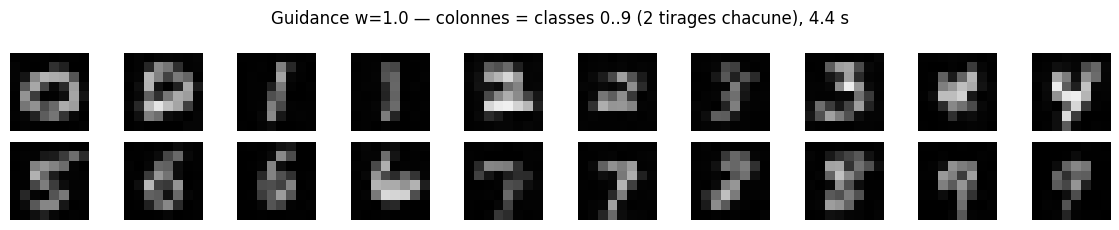

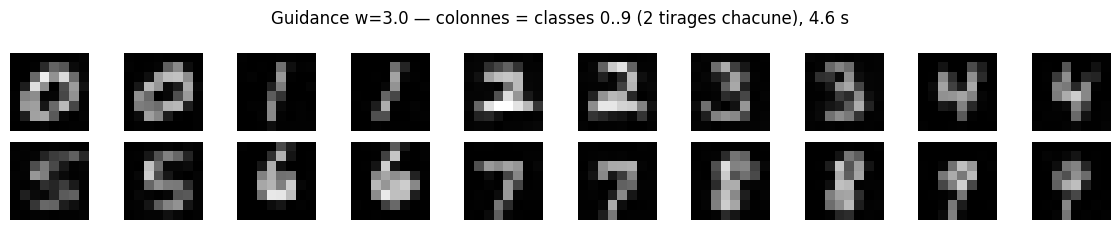

In [9]:
@torch.no_grad()
def echantillonner_guide(modele, etiquettes, w=1.0, taille=8, cst=None):
    """Sampler ancestral DDPM conditionnel avec classifier-free guidance.

    etiquettes : LongTensor (n,) des classes demandees.
    w          : poids de guidance. w=0 -> inconditionnel, w=1 -> conditionnel pur.
    Renvoie (images, duree).
    """
    cst = cst if cst is not None else const
    modele.eval()
    n = int(etiquettes.shape[0])
    etiquettes = etiquettes.to(DEVICE)
    nulles = torch.full_like(etiquettes, NULL_TOKEN)
    x = torch.randn(n, 1, taille, taille, device=DEVICE)
    t0 = time.time()
    for t_int in reversed(range(cst.T)):
        t = torch.full((n,), t_int, device=DEVICE, dtype=torch.long)
        eps_c = modele(x, t, etiquettes)          # prediction conditionnelle
        eps_u = modele(x, t, nulles)              # prediction inconditionnelle
        eps = eps_u + w * (eps_c - eps_u)         # la guidance, une interpolation
        beta_t = cst.betas[t].view(-1, 1, 1, 1)
        s_1a = cst.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        s_recip_a = torch.sqrt(1.0 / cst.alphas[t]).view(-1, 1, 1, 1)
        moyenne = s_recip_a * (x - beta_t / s_1a * eps)
        if t_int > 0:
            var = cst.posterior_variance[t].view(-1, 1, 1, 1)
            x = moyenne + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = moyenne
    return x, time.time() - t0


def grille(images, ncol=10, titre=None):
    """Affiche un lot d'images 8x8 en grille."""
    n = images.shape[0]
    nrow = (n + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.15 * ncol, 1.15 * nrow))
    axes = np.atleast_2d(axes)
    for i in range(nrow * ncol):
        a = axes[i // ncol, i % ncol]
        a.axis("off")
        if i < n:
            a.imshow(0.5 * (images[i, 0].cpu().numpy() + 1), cmap="gray", vmin=0, vmax=1)
    if titre:
        plt.suptitle(titre)
    plt.tight_layout(); plt.show()


# Colonnes = classes 0..9, une ligne par poids de guidance.
for w_demo in (1.0, 3.0):
    etq = torch.arange(10).repeat_interleave(2)          # 2 tirages par classe
    img, duree = echantillonner_guide(modele, etq, w=w_demo)
    grille(img, ncol=10, titre=f"Guidance w={w_demo} — colonnes = classes 0..9 (2 tirages chacune), {duree:.1f} s")

### Exercice 3 — la combinaison de guidance

À compléter : la fonction qui combine les deux prédictions. Elle doit reproduire exactement la formule du §3.

Les valeurs limites ne sont pas cosmétiques — ce sont elles qui attestent que la fonction est correcte :

- `mon_guidage(eps_u, eps_c, w=0)` doit rendre **exactement** `eps_u` ;
- `mon_guidage(eps_u, eps_c, w=1)` doit rendre **exactement** `eps_c`.

Si l'un des deux bords est faux, la guidance entière est fausse, et aucune courbe ne le dira : à $w=0{,}9$ ou $w=1{,}1$, une interpolation mal écrite reste plausible.


In [10]:
def mon_guidage(eps_uncond, eps_cond, w):
    """A COMPLETER : combiner les deux predictions selon le poids w."""
    # Indice : c'est une interpolation lineaire entre eps_uncond et eps_cond,
    #          mais extrapolable au-dela de w=1.
    # TODO etudiant
    resultat = None
    return resultat


eps_u_test = torch.zeros(4, 1, 8, 8)
eps_c_test = torch.ones(4, 1, 8, 8)
guidage_etudiant = mon_guidage(eps_u_test, eps_c_test, 2.0)

In [11]:
if guidage_etudiant is None:
    print("Exercice a completer : mon_guidage n'a pas encore ete implemente.")
    print("La suite du notebook utilise la reference (la ligne eps_u + w * (eps_c - eps_u)).")
else:
    bords = {}
    for w in (0.0, 1.0):
        val = mon_guidage(eps_u_test, eps_c_test, w)
        attendu = eps_u_test if w == 0.0 else eps_c_test
        bords[w] = val is not None and torch.allclose(val, attendu)
    carre = mon_guidage(eps_u_test, eps_c_test, 2.0)
    ok_extra = carre is not None and torch.allclose(carre, 2.0 * eps_c_test - eps_u_test)
    print("bord w=0 -> eps_uncond :", "PASS" if bords[0.0] else "FAIL")
    print("bord w=1 -> eps_cond   :", "PASS" if bords[1.0] else "FAIL")
    print("extrapolation w=2      :", "PASS" if ok_extra else "FAIL")

Exercice a completer : mon_guidage n'a pas encore ete implemente.
La suite du notebook utilise la reference (la ligne eps_u + w * (eps_c - eps_u)).


## 4. Mesurer la guidance sur trois axes

Un seul chiffre ne peut pas juger la guidance : c'est précisément parce qu'elle échange de la diversité contre de l'adhérence qu'un unique « score » est trompeur. On mesure donc trois choses, à effectif **égal**, sur les mêmes échantillons :

1. **MMD par classe** — l'écart aux vraies images de la classe demandée, avec le **plancher vrai/vrai mesuré au même effectif**. L'estimateur MMD utilisé ici inclut la diagonale $k(x,x)$ : son espérance porte un biais en $2/n$, donc comparer un plancher mesuré à $n$ avec des MMD mesurées à $n$ exige de les mesurer **au même $n$**. (C'est le défaut corrigé dans le 3.6c ; il ne se réintroduit pas ici.)

2. **Adhérence à l'étiquette** — la fraction des échantillons demandés comme classe $c$ que le **classifieur le plus bête possible** attribue à $c$ : plus proche centroïde, construit sur les vraies images. Ce classifieur ne sert pas à juger la qualité des images, seulement leur **classe**. Il a un plafond mesurable : sa précision sur de **vraies** images tenues à l'écart. Sans ce plafond, un taux de 70 % ne veut rien dire.

3. **Diversité intra-classe** — la distance moyenne entre paires d'échantillons d'une **même** classe. C'est l'axe qui baisse quand $w$ monte trop.

Et parce que la bande passante $\sigma$ du noyau MMD est un **choix** et non une mesure, le **rang** entre poids est revérifié à trois $\sigma$ — un classement qui ne survit pas au noyau n'est pas un classement.


In [12]:
def mmd_rbf(x, y, sigma=1.0):
    """Distance MMD a noyau RBF entre deux lots d'images aplaties.

    Identique a la fonction du 3.6c : meme instrument, donc resultats comparables.
    """
    x = x.reshape(x.shape[0], -1)
    y = y.reshape(y.shape[0], -1)

    def k(a, b):
        d2 = torch.cdist(a, b) ** 2
        return torch.exp(-d2 / (2 * sigma ** 2))

    return float(k(x, x).mean() + k(y, y).mean() - 2 * k(x, y).mean())


# --- le classifieur le plus simple possible : plus proche centroide de classe ----
def centroides(x, y, n_classes=10):
    return torch.stack([x[y == k].mean(dim=0) for k in range(n_classes)])


def classer(images, cent):
    """Classe chaque image par plus proche centroide (distance L2 sur les pixels)."""
    plat = images.reshape(images.shape[0], -1)
    ref = cent.reshape(cent.shape[0], -1)
    return torch.cdist(plat, ref).argmin(dim=1)


def diversite(images):
    """Distance L2 moyenne entre paires d'images d'un meme lot (diagonale exclue)."""
    plat = images.reshape(images.shape[0], -1)
    d = torch.cdist(plat, plat)
    n = plat.shape[0]
    return float(d.sum() / (n * (n - 1)))


# --- les lots reels, pris dans des tranches DISJOINTES ------------------------
# 0:20000     -> centroides
# 20000:30000 -> reference MMD par classe
# 55000:60000 -> plafond du classifieur, jamais vu ailleurs
X_TRAIN, Y_TRAIN = X_ALL[:20000].to(DEVICE), Y_ALL[:20000].to(DEVICE)
X_REF, Y_REF = X_ALL[20000:30000].to(DEVICE), Y_ALL[20000:30000].to(DEVICE)
X_EVAL, Y_EVAL = X_ALL[55000:60000].to(DEVICE), Y_ALL[55000:60000].to(DEVICE)

CENT = centroides(X_TRAIN, Y_TRAIN)
plafond = float((classer(X_EVAL, CENT) == Y_EVAL).float().mean())
print(f"plafond du classifieur (vraies images tenues a l'ecart) : {plafond:.3f}")

plafond du classifieur (vraies images tenues a l'ecart) : 0.824


In [13]:
N_PAR_CLASSE = 256
CLASSES = list(range(10))
POIDS = (0.0, 1.0, 2.0, 3.0, 5.0)


def lot_reel(x_src, y_src, k, n):
    """n vraies images de la classe k (tranche de reference, jamais utilisee ailleurs)."""
    return x_src[(y_src == k).nonzero(as_tuple=True)[0][:n]]


# Le plancher vrai/vrai se mesure A EFFECTIF EGAL avec les MMD des modeles. L'estimateur
# plug-in ci-dessus inclut la diagonale k(x,x), donc son esperance porte un biais en 2/n :
# un plancher mesure a n moitie porterait DEUX FOIS le biais des quantites qu'il minore,
# et paraitrait trop haut. C'est le defaut corrige dans le 3.6c ; il ne se reintroduit pas
# ici. On tire donc 2 x N_PAR_CLASSE vraies images par classe, coupees en deux moities
# disjointes de N_PAR_CLASSE.
REEL_C = {k: lot_reel(X_REF, Y_REF, k, 2 * N_PAR_CLASSE) for k in CLASSES}
REEL_A = {k: REEL_C[k][:N_PAR_CLASSE] for k in CLASSES}
REEL_B = {k: REEL_C[k][N_PAR_CLASSE:] for k in CLASSES}
PLANCHER_C = {k: mmd_rbf(REEL_A[k].cpu(), REEL_B[k].cpu()) for k in CLASSES}
plancher_moyen = float(np.mean(list(PLANCHER_C.values())))
print(f"plancher vrai/vrai moyen (n={N_PAR_CLASSE} contre {N_PAR_CLASSE}) : {plancher_moyen:.5f}")

resultats = []
gen_par_w = {}
for w in POIDS:
    etq = torch.arange(10, device=DEVICE).repeat_interleave(N_PAR_CLASSE)
    gen, duree = echantillonner_guide(modele, etq, w=w)
    gen = gen.cpu()
    # on garde le lot : la boucle sigma ci-dessous reutilise CES echantillons, elle
    # ne re-echantillonne pas. Re-tirer doublerait le cout pour rien, et surtout
    # comparerait deux tirages differents au lieu d'un seul.
    gen_par_w[w] = gen
    mmd_c, adh_c, div_c = {}, {}, {}
    for k in CLASSES:
        lot = gen[k * N_PAR_CLASSE:(k + 1) * N_PAR_CLASSE]
        mmd_c[k] = mmd_rbf(lot, REEL_A[k].cpu())
        adh_c[k] = float((classer(lot, CENT.cpu()) == k).float().mean())
        div_c[k] = diversite(lot)
    resultats.append({
        "w": w,
        "MMD": float(np.mean(list(mmd_c.values()))),
        "adherence": float(np.mean(list(adh_c.values()))),
        "diversite": float(np.mean(list(div_c.values()))),
        "s": duree,
    })
    print(f"  w={w:<4} MMD={resultats[-1]['MMD']:.5f}  adherence={resultats[-1]['adherence']:.3f}"
          f"  diversite={resultats[-1]['diversite']:.3f}  ({duree:.1f} s)")

# --- le rang survit-il au noyau ? trois bandes passantes, MEMES echantillons ----
print()
print("Rang des MMD selon la bande passante du noyau :")
for sigma in (0.5, 1.0, 2.0):
    valeurs = []
    for w in POIDS:
        lot_mmd = float(np.mean([
            mmd_rbf(gen_par_w[w][k * N_PAR_CLASSE:(k + 1) * N_PAR_CLASSE], REEL_A[k].cpu(), sigma)
            for k in CLASSES
        ]))
        valeurs.append(lot_mmd)
    meilleur = POIDS[int(np.argmin(valeurs))]
    print(f"  sigma={sigma:<5} " + " | ".join(f"w={w}: {v:.5f}" for w, v in zip(POIDS, valeurs))
          + f"  -> meilleur : w={meilleur}")

plancher vrai/vrai moyen (n=256 contre 256) : 0.01151


  w=0.0  MMD=0.05456  adherence=0.098  diversite=3.368  (8.0 s)


  w=1.0  MMD=0.02054  adherence=0.772  diversite=2.729  (7.8 s)


  w=2.0  MMD=0.05468  adherence=0.973  diversite=2.373  (7.9 s)


  w=3.0  MMD=0.09748  adherence=0.993  diversite=2.191  (7.9 s)


  w=5.0  MMD=0.16184  adherence=0.993  diversite=2.088  (7.8 s)

Rang des MMD selon la bande passante du noyau :
  sigma=0.5   w=0.0: 0.01228 | w=1.0: 0.00932 | w=2.0: 0.01405 | w=3.0: 0.02118 | w=5.0: 0.03504  -> meilleur : w=1.0


  sigma=1.0   w=0.0: 0.05456 | w=1.0: 0.02054 | w=2.0: 0.05468 | w=3.0: 0.09748 | w=5.0: 0.16184  -> meilleur : w=1.0
  sigma=2.0   w=0.0: 0.15448 | w=1.0: 0.02890 | w=2.0: 0.08543 | w=3.0: 0.15156 | w=5.0: 0.27199  -> meilleur : w=1.0


### Le test nul — avant de lire les courbes

Ce n'est pas un exercice : c'est la question qui décide de la lecture de tout le reste, et elle se répond avant de regarder les chiffres.

On a extrapolé au-delà du conditionnel ($w > 1$) et on a mesuré trois axes. **Lequel des trois devrait se dégrader si le réseau n'apprenait rien du tout**, c'est-à-dire si l'étiquette n'avait aucun effet sur sa prédiction ?

Répondez avant de regarder les courbes du §5 : si $\varepsilon_\theta(x_t,t,c) = \varepsilon_\theta(x_t,t,\varnothing)$ pour tout $c$, que valent l'adhérence et la diversité, et que devient la guidance ?

C'est le **test nul** de ce notebook. Il ne s'écrit pas en code — il s'écrit en une phrase, et il décide de la lecture de tout le reste.


## 5. Lire les courbes honnêtement

Trois axes, cinq poids, un seul réseau. Ce qui suit est la grille de lecture — **les chiffres sont dans les sorties ci-dessus**, et cette section ne les remplace pas.

1. **L'adhérence doit monter avec $w$, et partir de la chance.** À $w = 0$, l'étiquette est *littéralement ignorée* : la prédiction est $\varepsilon_\theta(x_t,t,\varnothing)$, la même pour les dix classes. L'adhérence doit donc tourner autour de $1/10$ — et si elle ne le fait pas, c'est la mesure qui est fausse, pas le modèle. C'est le contrôle le moins coûteux et le plus informatif du notebook.

2. **Le plafond du classifieur borne tout.** Sur de vraies images tenues à l'écart, le plus proche centroïde plafonne bien en dessous de 100 %. Une adhérence générée supérieure au plafond réel n'est pas un exploit : c'est le signe que les échantillons sont **plus faciles** que les vraies images — typiquement parce qu'ils sont moins variés. Ce qui est exactement ce que mesure l'axe 3.

3. **La diversité doit baisser.** Si elle ne baisse pas, la guidance mesurée n'extrapole rien. Une interpolation strictement entre $w=0$ et $w=1$ ne peut pas non plus expliquer une adhérence qui monte *au-delà* de celle de $w=1$ : c'est la signature de l'extrapolation.

4. **La MMD est un compromis, pas un classement.** Elle agrège fidélité et variété dans un seul nombre. Il est normal — et attendu — que son minimum ne tombe pas au même $w$ que le maximum d'adhérence. Un notebook qui ne présenterait que la MMD conclurait « $w^*$ est optimal » ; les trois axes ensemble disent « $w^*$ arbitre entre deux biens ».

5. **Le rang dépend du noyau, et il faut le dire.** La dernière boucle revérifie le classement à trois bandes passantes. Si le meilleur $w$ change avec $\sigma$, alors **le classement des poids est sous-déterminé par l'instrument** — exactement la limite que le 3.6c a rencontrée sur les schedules et qui a ouvert l'issue #16137. Ici, elle est mesurée dès le premier passage au lieu d'être découverte après coup.

Ce que ce notebook **ne** prétend pas : que la guidance améliore les images. Elle déplace un curseur sur un compromis, et on a mesuré les deux côtés du curseur.


## 6. Ce que `diffusers` cache

Le tableau ci-dessous est la carte des endroits où une bibliothèque peut surprendre : à gauche ce qu'on a écrit, à droite le nom public que cela porte.

| Ce qu'on a écrit ici | Nom dans `diffusers` | Ce qui reste caché |
|---|---|---|
| `nn.Embedding(n_classes + 1, temb)` + somme au contexte | `UNet2DModel(class_embedder_type=...)`, `class_labels=` | la gestion du **token nul** et le placement de l'embedding |
| `abandon = rand < p_uncond` | argument d'entraînement `class_labels` + `dropout` interne | le taux, souvent non exposé |
| `eps_u + w * (eps_c - eps_u)` | `guidance_scale=w` | rien — c'est cette ligne |
| deux passes avant par pas | — | le **coût** : `guidance_scale > 1` double le temps d'échantillonnage |
| le sampler ancestral du 3.6c | `DDPMScheduler.step()` | les coefficients $\beta_t$, $\bar\alpha_t$, $\tilde\beta_t$ |

La dernière ligne du tableau est la raison d'être des notebooks from scratch de cette série : `guidance_scale` a l'air d'un paramètre de qualité. C'est un **poids d'interpolation**, et on vient de voir sur trois axes ce qu'il échange.


## Synthèse

Ce que ce notebook a écrit, et qui n'existait pas dans les notebooks précédents de la série :

| Mécanisme | Ligne(s) qui le porte(nt) | Ce qu'il apporte |
|---|---|---|
| Conditionnement par étiquette | l'addition `temb(t) + emb_classe(c)` | le réseau sait *quelle* classe produire |
| Token nul $\varnothing$ | une ligne de table en plus (`n_classes + 1`) | rend la guidance possible **sans** classifieur |
| Abandon d'étiquette | `torch.where(abandon, NULL_TOKEN, yb)` | les deux fonctions, un seul jeu de poids |
| Classifier-free guidance | `eps_u + w * (eps_c - eps_u)` | déplace le curseur fidélité / variété |
| Mesure à trois axes | MMD par classe, adhérence, diversité | empêche de conclure sur un seul nombre |

**Le résultat à retenir n'est pas un chiffre, c'est un déplacement** : la guidance n'est pas un réglage de qualité, c'est un arbitrage. Le notebook précédent (`3.6c`) comparait deux schedules avec un seul instrument — et l'instrument s'est révélé sous-déterminer la conclusion. Ici, l'instrument est plural dès le départ.

### Pour aller plus loin dans la série

- [3.6](3.6-Modeles-Generatifs.ipynb) — panorama (VAE, GAN, flows, diffusion, EBM) en NumPy pur
- [3.6b](3.6b-Modeles-Generatifs-PyTorch.ipynb) — le versant framework, mêmes cibles, mêmes métriques
- `3.6c` — le DDPM inconditionnel, schedules comparés
- `3.6d` — le même objet en temps continu (score, Langevin, Euler-Maruyama)

Le pendant industriel — `diffusers` avec `DDPMScheduler` et `UNet2D` — est l'objet du bloc B de l'issue #16056.
